### Model inspired by:

- [1] Offshore Pipelaying Dynamics. Gullik Anthon Jensen
- [2] A nonlinear PDE formulation for offshore vessel pipeline installation. Gullik A. Jensen et al
- [3] Modeling and Control of Offshore Pipelay Operations Based on a Finite Strain Pipe Model. Gullik A. Jensen

### Implementation aspects:

- The model can be applied to normal dynamic pipelay condition as a rough estimate

In [1]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
import scipy
from datetime import datetime
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy import interpolate
import plotly.graph_objects as go
from scipy.interpolate import interp1d
from scipy import integrate

In [2]:
import sys

In [3]:
sys.path.insert(0, "../../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src/python_vehicle_simulator")
sys.path.insert(0, "../../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src")

In [4]:
from python_vehicle_simulator.vehicles import *
from python_vehicle_simulator.lib import *
from python_vehicle_simulator.lib.gnc import ssa

### Input data:

In [5]:
mp = 41.9       #  (submerged pipe weight) [kg/m]
N = 20      # number of modelling nodes

In [6]:
qw = 1025 # Water density [kg/m3]
d0 = 0.2731 # Outer diameter of pipe, [m]
dI= (273.1-15.9*2)/1000 # Inner diameter of pipe, [m]

In [7]:
# Underwater current: 
dv1_curr = 0
dv2_curr = 0
dv3_curr = 0

In [8]:
Fx_0 = 449*1000
Fy_0 = 0.7*Fx_0
LTD = 387

In [9]:
E = 207e9
G = 79.3e9

In [10]:
# integration parameters
tspan = (0., 15)

### Main functions:

In [11]:
Ar=np.pi*(d0/2)**2

In [12]:
def Πe(φ,θ,ψ):
    return np.array([[np.cos(θ),0,np.cos(φ)*np.sin(θ)],
                  [0,1,-np.sin(φ)],
                  [-np.sin(θ),0,np.cos(φ)*np.cos(θ)]])

In [13]:
def Ret_e_t(φ,θ,ψ):
        Cφ=np.array([[1,0,0],
                      [0,np.cos(φ),-np.sin(φ)],
                      [0,np.sin(φ),np.cos(φ)]])

        Cθ=np.array([[np.cos(θ),0,np.sin(θ)],
                      [0,1,0],
                      [-np.sin(θ),0,np.cos(θ)]])

        Cψ=np.array([[np.cos(ψ),-np.sin(ψ),0],
                      [np.sin(ψ),np.cos(ψ),0],
                      [0,0,1]])

        return Cθ @ Cφ @ Cψ

In [14]:
diag_J_t_rho = 1e2*np.array([1, 1, 2]) # [m^4] 
J_t_rho = np.diag(diag_J_t_rho)

In [15]:
diag_CT = 1e9*np.array([1, 1, 1 ])  
CT=np.diag(diag_CT)

In [16]:
diag_CR = 1e11*np.array([1, 1, 1]) 
CR=np.diag(diag_CR)

In [17]:
diag_DT = 1.5*np.array([1, 1, 1])
DT=np.diag(diag_DT)

In [18]:
diag_DR = 1.5*np.array([1, 1, 1])
DR=np.diag(diag_DR)

In [19]:
def I_e_rho(φ,θ,ψ):
    return Ret_e_t(φ,θ,ψ) @ J_t_rho @ Ret_e_t(φ,θ,ψ).T

In [20]:
def phi(x,y,z): return np.array([x,y,z]) 
def theta(φ,θ,ψ): return np.array([φ,θ,ψ]) 

In [21]:
def ωe(φ,θ,ψ): 
    return Πe(φ,θ,ψ)@theta(φ,θ,ψ)

In [22]:
def S(a1, a2, a3 ):
    return np.array([[0, -a3, a2 ],
                         [a3, 0, -a1],
                        [-a2, a1, 0]])

In [23]:
def d_s_phi(x1,y1,z1,x2,y2,z2,h):
#     a1, a2, a3 = ωe(φ,θ,ψ)
#     return S(a1, a2, a3 )@phi(x,y,z)
    return 1/h*(phi(x1,y1,z1)-phi(x2,y2,z2))

In [24]:
# def ne(x, y, z, φ, θ, ψ,h):
#     return (Ret_e_t(φ,θ,ψ)@CT@Ret_e_t(φ,θ,ψ).T@(d_s_phi(x,y,z,φ,θ,ψ,h).reshape(3,1)
#             -Ret_e_t(φ,θ,ψ)@np.array([1,0,0]).reshape(3,1))).reshape(1,3)
def ne(x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2,h):
    return (Ret_e_t(φ1,θ1,ψ1)@CT@Ret_e_t(φ1,θ1,ψ1).T@(d_s_phi(x1,y1,z1,x2,y2,z2,h).reshape(3,1)
            -Ret_e_t(φ1,θ1,ψ1)@np.array([1,0,0]).reshape(3,1))).reshape(1,3)

In [25]:
def me( φ, θ, ψ):
    return Ret_e_t(φ,θ,ψ)@CR@Ret_e_t(φ,θ,ψ).T@ωe(φ,θ,ψ)

In [26]:
def dΠ(φ, θ, ψ, dφ, dθ, dψ):
    return np.array([[-np.sin(θ)*dθ,0,-np.sin(φ)*dφ*np.sin(θ)+np.cos(φ)*np.cos(θ)*dθ],
                  [0,0,-np.cos(φ)*dφ],
                  [-np.cos(θ)*dθ,0,-np.sin(φ)*dφ*np.cos(θ)-np.cos(φ)*np.sin(θ)*dθ]])

In [27]:
fe_g = np.array([0,0, -mp*9.81])          

In [28]:
def f_t_d(dx,dy,dz): 
    
    vr1 = dx - dv1_curr
    vr2 = dy - dv2_curr  
    vr3 = dz - dv3_curr
    A = np.array([np.abs(vr1) * vr1,
                  np.sqrt(vr2**2 + vr3**2) * vr2,
                 np.sqrt(vr2**2 + vr3**2) * vr3])
    return 0.5 * d0 * qw * (DT@ A)

In [29]:
def sigma(x,y,z):
    e3 = np.array([0,0,1])
    
    k = phi(x,y,z) @ e3+d0/2
    
    fe_g2 = np.linalg.norm(fe_g, ord=2)
   
    if k<0:
        k0=0
    elif 0<=k<=d0/20:
        k0=(fe_g2*10*k**2)/((d0/8-d0/40)*(d0))
    else:
        k0=(fe_g2*(k-d0/40))/(d0/8-d0/40)
            
    result = k0 * e3 
   
    return result  

### Static solution

In [30]:
def catenary(x,Ws,Fh):
    return (Fh/Ws)*(np.cosh(x*Ws/Fh)-1)

In [31]:
mi = [mp for i in range(N)]

In [32]:
pipe_weight_per_unit_length = mi #  (submerged) [kg/m]  # 113.07 - not submerged

In [33]:
Ws = np.array(pipe_weight_per_unit_length)*9.81 # [N/m]

In [34]:
horizontal_length=2*(Fx_0/Ws[0])*(np.sinh(LTD*Ws[0]/(2*Fx_0)))

In [35]:
delta_x=horizontal_length/(N-1)

In [36]:
x0=[i*delta_x for i in range(N)]
z0=[]

for i in range(len(x0)):
    z0.append(catenary(x0[i],Ws[0],Fx_0))

length_p=[]
for i in range(1,len(z0)):
    length_p.append(np.sqrt((x0[i]-x0[i-1])**2+(z0[i]-z0[i-1])**2))

In [37]:
cum_len = 0
length_p1=[0]
for i in range(len(length_p)):
    cum_len+=length_p[i]
    length_p1.append(cum_len)

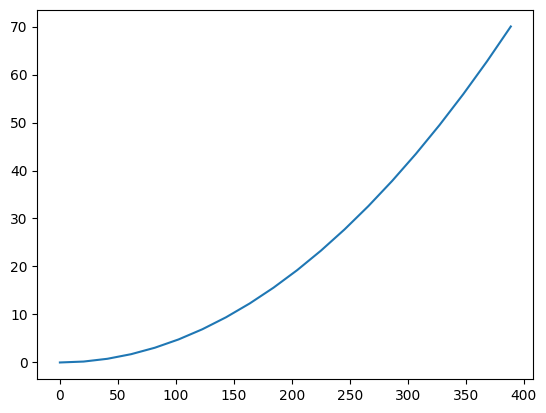

In [38]:
plt.plot(x0, z0)
plt.show()

In [39]:
q0=np.zeros(12*N)

In [40]:
for j in range(1,12):
    if j==1:
        q0[(j-1)*N:j*N]=x0
    elif j==5:
        q0[(j-1)*N:j*N]=z0

In [41]:
h = delta_x

In [42]:
h

20.475110824379673

In [43]:
def fun1(x_int, φ, θ, ψ):
    x_arr = np.atleast_1d(x_int) 
    num_pts = len(x_arr)
    
    coeff_A = mp * 1/2 * (1 + x_arr) * 1/2 * (1 - x_arr)  
    coeff_D = 1/2 * (1 + x_arr) * 1/2 * (1 - x_arr)      
    
   
    id3 = np.identity(3)
    zeros3 = np.zeros((3, 3))
    mat_D = I_e_rho(φ, θ, ψ) @ Πe(φ, θ, ψ)
    
    A = np.multiply.outer(id3, coeff_A)
    B = np.zeros((3, 3, num_pts))
    D = np.multiply.outer(mat_D, coeff_D)
    
    block_top = np.concatenate([A, B], axis=1)     
    block_bottom = np.concatenate([B, D], axis=1)  
    total_matrix = np.concatenate([block_top, block_bottom], axis=0) 
    
    return h / 2 * total_matrix


def fun2(x_int, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, h):
    x_arr = np.atleast_1d(x_int)  
    num_pts = len(x_arr)
    
    id3 = np.identity(3)
    zeros3 = np.zeros((3, 3))
    mat_S = S(*d_s_phi(x1, y1, z1, x2, y2, z2, h))
    
    coeff_C = -1/2 * (1 + x_arr)  
    
    A = np.repeat(id3[:, :, np.newaxis], num_pts, axis=2)
    B = np.zeros((3, 3, num_pts))
    C = np.multiply.outer(mat_S, coeff_C)  
    
    block_top = np.concatenate([A, B], axis=1)      
    block_bottom = np.concatenate([C, A], axis=1)   
    total_matrix = np.concatenate([block_top, block_bottom], axis=0)  
    
    total_matrix = (h / 2) * total_matrix
    
    vec_ne = np.asarray(ne(x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, h))
    vec_me = np.asarray(me(φ1, θ1, ψ1))
    right_vector = np.concatenate((vec_ne, vec_me), axis=None) 
    
    return np.einsum('ijk,j->ik', total_matrix, right_vector)


def fun3(x_int, φ, θ, ψ, dφ, dθ, dψ):
  
    x_arr = np.atleast_1d(x_int)  
    num_pts = len(x_arr)
    
    A = np.zeros((3, num_pts))
    

    mat_prod = I_e_rho(φ, θ, ψ) @ dΠ(φ, θ, ψ, dφ, dθ, dψ) 
    vec_diff = np.array([dφ, dθ, dψ])                     
    static_B = mat_prod @ vec_diff                        
    
    coeff_B = 1/2 * (1 + x_arr)  
    
    B = np.multiply.outer(static_B, coeff_B)  
    
    total_matrix = np.concatenate((A, B), axis=0)  
    
    return (h / 2) * total_matrix



def fun4(x_int, φ, θ, ψ, dφ, dθ, dψ):
    A = np.zeros(3)
    ang_vel = Πe(φ, θ, ψ) @ np.array([dφ, dθ, dψ])
    B_base = S(*ang_vel) @ (I_e_rho(φ, θ, ψ) @ ang_vel)
    
    x_arr = np.atleast_1d(x_int)[:, np.newaxis] 
    B_scaled = 1/2 * (1 + x_arr) * B_base 
    A_repeated = np.tile(A, (len(B_scaled), 1)) 
    
    result = h / 2 * np.hstack((A_repeated, B_scaled)) 
    
    return result if np.isscalar(x_int) else result.T


# def fun5(x_int):
#     B=np.zeros(3)   
#     A=1/2*(1+x_int)*fe_g
#     return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)

def fun5(x_int):
    B = np.zeros(3)   
    
    x_arr = np.atleast_1d(x_int)[:, np.newaxis] 
    A_scaled = 1/2 * (1 + x_arr) * fe_g
    B_repeated = np.tile(B, (len(A_scaled), 1)) 
    
    result = h / 2 * np.hstack((A_scaled, B_repeated))
    
    return result if np.isscalar(x_int) else result.T


def fun6(x_int, φ, θ, ψ, dx, dy, dz, dφ, dθ, dψ):
    A_base = Ret_e_t(φ, θ, ψ) @ f_t_d(dx, dy, dz)
    B_base = DR @ Πe(φ, θ, ψ) @ np.array([dφ, dθ, dψ])
    
    x_arr = np.atleast_1d(x_int)[:, np.newaxis] 
    
    A_scaled = 1/2 * (1 + x_arr) * A_base 
    B_scaled = 1/2 * (1 + x_arr) * B_base 
    
    result = h / 2 * np.hstack((A_scaled, B_scaled)) 
    
    return result[0] if np.isscalar(x_int) else result.T



def fun7(x_int, x, y, z):
    A_base = sigma(x, y, z) 
    B_base = np.zeros(3)   
    
    x_arr = np.atleast_1d(x_int)[:, np.newaxis] 
    
    A_scaled = 1/2 * (1 + x_arr) * A_base          
    B_scaled = np.tile(B_base, (len(A_scaled), 1)) 
    
    result = h / 2 * np.hstack((A_scaled, B_scaled))
    
    return result if np.isscalar(x_int) else result.T







# def fun1(x_int,φ,θ,ψ):
#     A=mp*1/2*(1+x_int)*1/2*(1-x_int)*np.identity(3)
#     B=np.zeros((3,3))
#     D=1/2*(1+x_int)*1/2*(1-x_int)*I_e_rho(φ,θ,ψ)@Πe(φ,θ,ψ)
#     return h/2*np.block([[A, B], [B, D]])


def fun1_h(x_int,φ1,θ1,ψ1,φ2,θ2,ψ2):
    return 0.5*((1-x_int)*fun1(x_int,φ1,θ1,ψ1)+(1+x_int)*fun1(x_int,φ2,θ2,ψ2))


# def fun2(x_int,x1,y1,z1, φ1, θ1, ψ1, x2, y2, z2 ):
#     A=1/h*np.identity(3)
#     B=np.zeros((3,3))
#     C=-1/2*(1+x_int)*S(*d_s_phi(x1, y1, z1, x2, y2, z2,h))
#     return h/2*np.block([[A, B], [C, A]])@np.concatenate((np.asarray(ne(x1, y1, z1, φ1, θ1, ψ1)),
#                                                           np.asarray(me( φ1, θ1, ψ1))), axis=None)

def fun2_h(x_int,x1,y1,z1,φ1,θ1,ψ1,x2,y2,z2, φ2,θ2,ψ2,h):
    return 0.5*((1-x_int)*fun2(x_int,x1,y1,z1,φ1,θ1,ψ1,x2,y2,z2,h)
                +(1+x_int)*fun2(x_int,x2,y2,z2,φ2,θ2,ψ2,x2,y2,z2,h))


# def fun3(x_int,φ,θ,ψ, dφ, dθ, dψ):
#     A=np.zeros(3)
#     B=1/2*(1+x_int)*I_e_rho(φ,θ,ψ)@dΠ(φ, θ, ψ, dφ, dθ, dψ)@np.array([dφ, dθ, dψ])
#     return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)


def fun3_h(x_int,φ1,θ1,ψ1, dφ1, dθ1, dψ1,φ2,θ2,ψ2, dφ2, dθ2, dψ2):
    return 0.5*((1-x_int)*fun3(x_int,φ1,θ1,ψ1, dφ1, dθ1, dψ1)+(1+x_int)*fun3(x_int,φ2,θ2,ψ2, dφ2, dθ2, dψ2))


# def fun4(x_int,φ,θ,ψ, dφ, dθ, dψ):
#     A=np.zeros(3)   
#     B=1/2*(1+x_int)*S(*(Πe(φ, θ, ψ)@np.array([dφ, dθ, dψ])))@(I_e_rho(φ,θ,ψ)@Πe(φ, θ, ψ)@np.array([dφ, dθ, dψ])).T
#     return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)


def fun4_h(x_int,φ1,θ1,ψ1, dφ1, dθ1, dψ1,φ2,θ2,ψ2, dφ2, dθ2, dψ2):
    return 0.5*((1-x_int)*fun4(x_int,φ1,θ1,ψ1, dφ1, dθ1, dψ1)+(1+x_int)*fun4(x_int,φ2,θ2,ψ2, dφ2, dθ2, dψ2))


# def fun5(x_int):
#     B=np.zeros(3)   
#     A=1/2*(1+x_int)*fe_g
#     return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)


def fun5_h(x_int):
    return fun5(x_int)


# def fun6(x_int,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ):
#     A=1/2*(1+x_int)* Ret_e_t(φ,θ,ψ)@f_t_d(dx,dy,dz)
#     B=1/2*(1+x_int)* DR@ Πe(φ, θ, ψ)@  np.array([dφ, dθ, dψ])
#     return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)


def fun6_h(x_int,φ1,θ1,ψ1, dx1, dy1, dz1, dφ1, dθ1, dψ1, φ2, θ2, ψ2, dx2, dy2, dz2, dφ2, dθ2, dψ2):
    return  0.5*((1-x_int)*fun6(x_int,φ1,θ1,ψ1, dx1, dy1, dz1, dφ1, dθ1, dψ1)+
                 (1+x_int)*fun6(x_int,φ2,θ2,ψ2, dx2, dy2, dz2, dφ2, dθ2, dψ2))


# def fun7(x_int,x,y,z):
#     A=1/2*(1+x_int)*sigma(x,y,z)
#     B=np.zeros(3) 
#     ans=h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
#     return ans


def fun7_h(x_int,x1,y1,z1,x2,y2,z2):
    return 0.5*((1-x_int)*fun7(x_int,x1,y1,z1)+(1+x_int)*fun7(x_int,x2,y2,z2))

In [44]:
def static_solution(Q): 
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    f1=[] 
    f2=[]
    f3=[]
    f4=[]
    f5=[]
    f6=[]
#     f7=[] 


    for j in range(N):
        
#         f1.append(fun1_h(-1/np.sqrt(3),φ[j-1],θ[j-1],ψ[j-1], φ[j], θ[j], ψ[j])
#                   + fun1_h(1/np.sqrt(3),φ[j-1],θ[j-1],ψ[j-1], φ[j], θ[j], ψ[j]))
        
        f1.append(integrate.fixed_quad(lambda x_int: fun1_h(x_int, φ[j-1],θ[j-1],ψ[j-1], φ[j], θ[j], ψ[j]),-1.0,1.0,n=2)[0])

        
        if j==0:   
            f2.append(np.zeros(6))
            f3.append(np.zeros(6))
            f4.append(np.zeros(6))
            f5.append(np.zeros(6))
            f6.append(np.zeros(6))
#             f7.append(np.zeros(6))     
        else:    
#             f2.append(fun2_h(-1/np.sqrt(3),x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],φ[j],θ[j],ψ[j])+
#                      fun2_h(1/np.sqrt(3),x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],φ[j],θ[j],ψ[j]))

           
            f2.append(integrate.fixed_quad(lambda x_int:fun2_h(x_int, x[j-1], y[j-1], z[j-1], φ[j-1], θ[j-1], ψ[j-1], 
                                                               x[j], y[j],z[j],φ[j],θ[j],ψ[j],h),-1.0,1.0,n=1)[0])
            f3.append(integrate.fixed_quad(lambda x_int:fun3_h(x_int,φ[j-1],θ[j-1],ψ[j-1],dφ[j-1],dθ[j-1],dψ[j-1],φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]),-1.0,1.0,n=2)[0])
            f4.append(integrate.fixed_quad(lambda x_int:fun4_h(x_int,φ[j-1],θ[j-1],ψ[j-1],dφ[j-1],dθ[j-1],dψ[j-1],φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]),-1.0,1.0,n=2)[0])
            f5.append(integrate.fixed_quad(lambda x_int:fun5_h(x_int),-1.0,1.0,n=2)[0])
            f6.append(integrate.fixed_quad(lambda x_int:fun6_h(x_int, φ[j-1],θ[j-1],ψ[j-1],dx[j-1],dy[j-1],dz[j-1],dφ[j-1], dθ[j-1], dψ[j-1], φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j], dθ[j], dψ[j]),-1.0,1.0,n=2)[0])
#             f2.append(2*fun2_h(0,x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],φ[j],θ[j],ψ[j]))

#             f3.append(fun3_h(-1/np.sqrt(3),φ[j-1],θ[j-1],ψ[j-1],dφ[j-1],dθ[j-1],dψ[j-1],φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]) 
#                       +fun3_h(1/np.sqrt(3),φ[j-1],θ[j-1],ψ[j-1],dφ[j-1],dθ[j-1],dψ[j-1],φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]))
#             f4.append(fun4_h(-1/np.sqrt(3),φ[j-1],θ[j-1],ψ[j-1],dφ[j-1],dθ[j-1],dψ[j-1],φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j])
#                                 +fun4_h(1/np.sqrt(3),φ[j-1],θ[j-1],ψ[j-1],dφ[j-1],dθ[j-1],dψ[j-1],φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]))
#             f5.append(fun5_h(-1/np.sqrt(3))+fun5_h(1/np.sqrt(3)))
#             f6.append(fun6_h(-1/np.sqrt(3),φ[j-1],θ[j-1],ψ[j-1],dx[j-1],dy[j-1],dz[j-1],dφ[j-1], dθ[j-1], dψ[j-1],φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j], dθ[j], dψ[j])
#                                 +fun6_h(1/np.sqrt(3),φ[j-1],θ[j-1],ψ[j-1],dx[j-1],dy[j-1],dz[j-1],dφ[j-1], dθ[j-1], dψ[j-1],φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j], dθ[j], dψ[j]))
#             f7.append(fun7_h(-1/np.sqrt(3),x[j-1],y[j-1],z[j-1],x[j],y[j],z[j])+fun7_h(1/np.sqrt(3),x[j-1],y[j-1],z[j-1],x[j],y[j],z[j]))

    f2=np.vstack(f2) 
    f3=np.vstack(f3)
    f4=np.vstack(f4) 
    f5=np.vstack(f5)
    f6=np.vstack(f6) 
#     f7=np.vstack(f7) 

    f1 = np.array(f1)
    f1 = np.stack(f1, axis=0)
    
#     ddx,ddy,ddz, ddφ,ddθ,ddψ = np.linalg.solve(f1,f2+f3+f4+f5+f6
# #                                               +f7
#                                               ).T
    
    ddx=np.zeros(N)
    ddy=np.zeros(N)
    ddz=np.zeros(N)
    ddφ=np.zeros(N)
    ddθ=np.zeros(N)
    ddψ=np.zeros(N)
    

    for i in range(N):    
        ddx[i],ddy[i],ddz[i], ddφ[i],ddθ[i],ddψ[i] =  scipy.sparse.linalg.spsolve(scipy.sparse.csr_matrix(f1[i]), 
                                                           (
                                                               f2[i]
                                                               +f3[i]
                                                               +f4[i]
                                                               +f5[i]
                                                               +f6[i]
#                                                     +f7[i]
                                                   ).reshape(6,1))
  

    ans=np.concatenate([dx, ddx, 
                        dy, ddy,  
                        dz, ddz, 
                        dφ, ddφ,  
                        dθ, ddθ, 
                        dψ, ddψ,  
                       ], axis=0)
    
    return ans

In [45]:
# root_ = root(static_solution, q0
#              , method='lm'
#             )

In [46]:
# root_

In [47]:
# x0_, z0_=root_.x[:N],root_.x[4*N:5*N]

In [48]:
# q0 = root_.x                                         # start from static solution

In [49]:
# plt.plot(x0_, z0_)
# plt.show()

### Vessle Simulation

In [50]:
sampleTime = 0.01              # sample time [seconds]
Number = 6000                      # number of samples

In [51]:
Number*sampleTime

60.0

In [52]:
vehicle=semisub('DPcontrol',1,-1,0.0,0,0)

In [53]:
[simTime, simData] = simulate(Number, sampleTime, vehicle)

In [54]:
simData.shape 

(6001, 24)

In [55]:
ans_t=[]
sum_=0
for i in range(simData.shape[0]):
    ans_t.append(sum_)
    sum_+=sampleTime

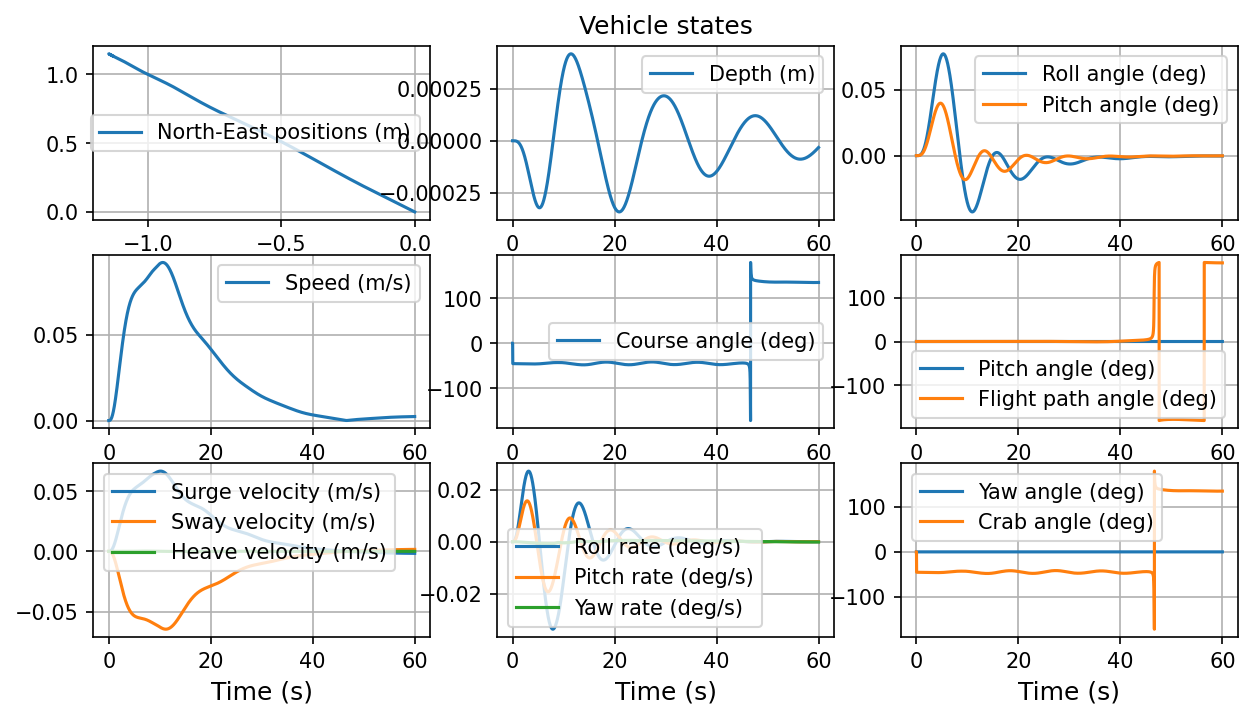

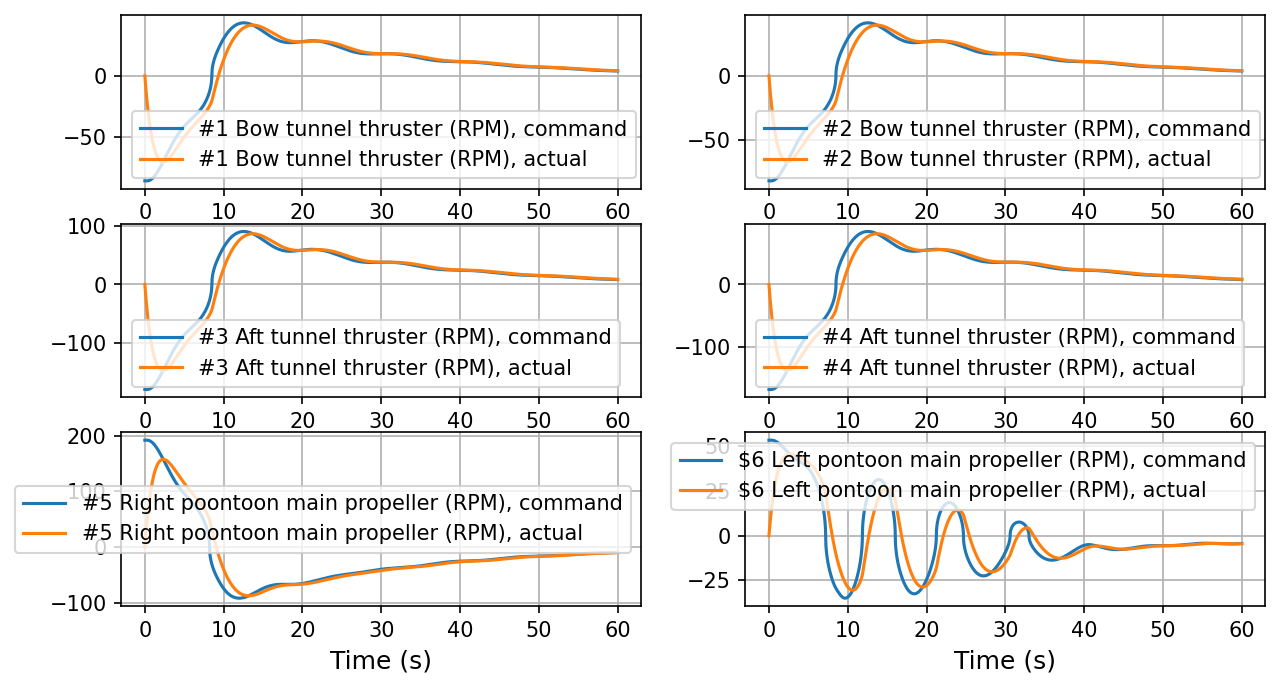

In [56]:
plotVehicleStates(simTime, simData, 1)
plotControls(simTime, simData, vehicle, 2)

In [57]:
numDataPoints = 5                 # number of 3D data points
FPS = 10                            # frames per second (animated GIF)
filename = '3D_animation.gif'       # data file for animated GIF
browser = 'safari'

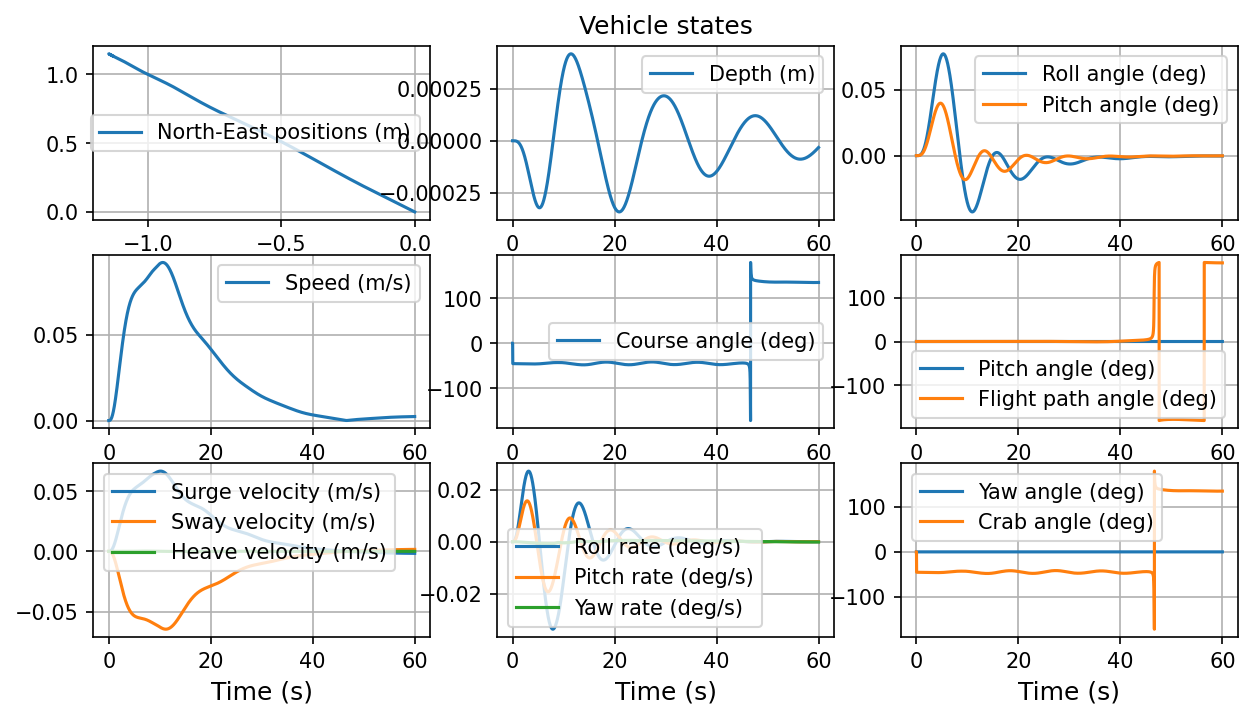

In [58]:
plotVehicleStates(simTime, simData, 3)

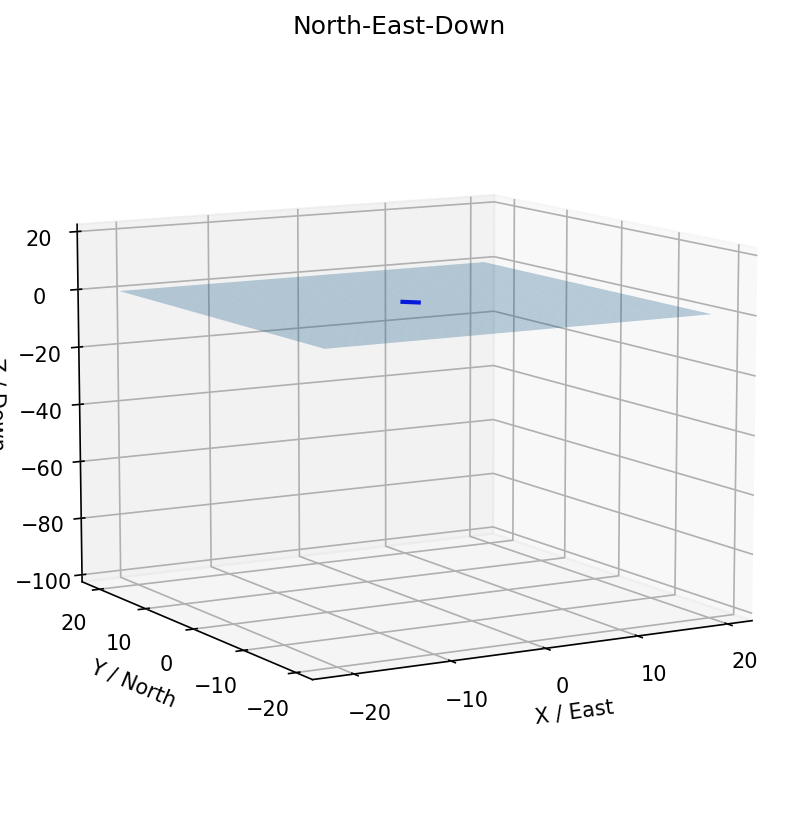

In [59]:
plot3D(simData, numDataPoints, FPS, filename, 3)

In [60]:
simData.shape

(6001, 24)

In [61]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

In [62]:
class MyTime:
    def __init__(self):
        self.progression = [i for i in range(650)]
        self.wall_clock = datetime.now()
        self.top_tension = 0
        self.sagbend_strain = 0
        self.my_iter = 0
        self.force_factor = 1

In [63]:
vessel_motion_func = interp1d(
    ans_t, simData[:, 18:24], axis=0, kind="linear", fill_value="extrapolate"
)

### Dynamic Simulation

In [64]:
"""
Corrected dynamic FEM core for the pipelay PDE model (Jensen et al. 2010).

This is a drop-in replacement for the notebook's `dynamic_func` (cell 83) and
its supporting helpers. It fixes four issues found in the original draft:

  1. `d.reshape(6,N)` -> `d.reshape(N,6).T`
     The global DOF/residual vector is NODE-BLOCKED (node0's 6 dofs, then
     node1's 6 dofs, ...) -- that's what Assemble() builds and what pdof/fdof
     assume. `reshape(6,N)` silently scrambles accelerations across nodes
     and dof types. This alone invalidates any dynamic result from the
     original draft.

  2. The internal elastic force (tension `n` + bending moment `m`, built
     from CT/CR) was computed (`f2`) but never added into `F`. Without it,
     the pipe has no bending/axial stiffness feedback at all -- only
     gravity, drag, seabed spring, rotational damping and inertial/Coriolis
     terms drove the original "dynamics". Re-enabled here.

  3. `me()` computed the bending moment from a SINGLE node's raw Euler
     angles via the same Pi_e(phi,theta,psi) @ [phi,theta,psi] construction
     used elsewhere for angular VELOCITY (with dphi,dtheta,dpsi). Per the
     paper (eq. 14-15, 24), the stress couple must depend on CURVATURE --
     a spatial derivative of orientation between adjacent nodes -- exactly
     analogous to how `ne()` correctly differences POSITION between nodes
     (`d_s_phi`). Fixed: curvature is now (Theta_{j} - Theta_{j-1})/h,
     mapped through Pi_e evaluated at the element's mean orientation.

  4. The assembly loop `for j in range(1, N): ... f2[start:end] += ...`
     with `start = 6*(j-1)` only ever wrote into node j-1's slot. Node
     N-1 (the last / vessel-end node) therefore never received its own
     gravity, drag, rotational-damping, seabed, or gyroscopic contribution
     in the original code -- only the mass matrix (via Assemble, which does
     write both diagonal blocks) and the vessel forcing f8 touched it.
     Fixed: every element-distributed force is now scattered to BOTH
     endpoint nodes, matching a standard 2-node Galerkin assembly.

Scope note: the shear-coupling term <n, S(u') delta_theta> (paper eq. 97,
second term inside G_stat) is left out for now -- it couples axial/shear
force into the rotational residual through the interpolated test function,
which is a smaller correction on top of fixes 2-4 above. Flagged in-code
below (`# NOTE: shear-coupling term omitted`) so it's easy to add later.
"""

import numpy as np
from scipy import integrate

# ---------------------------------------------------------------------
# 1. Physical constants / pipe properties (same values as the notebook)
# ---------------------------------------------------------------------
mp = 41.9                                  # submerged pipe weight [kg/m]
# N = 20                                     # number of modelling nodes

qw = 1025.0                                # water density [kg/m3]
d0 = 0.2731                                # outer diameter [m]
dI = (273.1 - 15.9 * 2) / 1000             # inner diameter [m]
Ar = np.pi * (d0 / 2) ** 2

E = 207e9
G = 79.3e9

dv1_curr = dv2_curr = dv3_curr = 0.0       # current velocity components

diag_J_t_rho = 1e2 * np.array([1, 1, 2])
J_t_rho = np.diag(diag_J_t_rho)

diag_CT = 1e9 * np.array([1, 1, 1])
CT = np.diag(diag_CT)

diag_CR = 1e11 * np.array([1, 1, 1])
CR = np.diag(diag_CR)

diag_DT = 1.5 * np.array([1, 1, 1])
DT = np.diag(diag_DT)

diag_DR = 1.5 * np.array([1, 1, 1])
DR = np.diag(diag_DR)

fe_g = np.array([0, 0, -mp * 9.81])

# `h` (element length) must match whatever the static solve used, e.g.:
# h = length_p1[-1] / N
# It is imported/assigned by the notebook before this module is used.


# ---------------------------------------------------------------------
# 2. Kinematics helpers (unchanged from the notebook -- these were correct)
# ---------------------------------------------------------------------
def Pi_e(phi, theta, psi):
    """Maps Euler angle rates to angular velocity: w = Pi_e @ Theta_dot (eq. 101)."""
    return np.array([
        [np.cos(theta), 0, np.cos(phi) * np.sin(theta)],
        [0, 1, -np.sin(phi)],
        [-np.sin(theta), 0, np.cos(phi) * np.cos(theta)],
    ])


def Ret_e_t(phi, theta, psi):
    """R^e_t(Theta) = Re2(theta) Re1(phi) Re3(psi), zxy-convention (eq. 98-99)."""
    Cphi = np.array([[1, 0, 0],
                      [0, np.cos(phi), -np.sin(phi)],
                      [0, np.sin(phi), np.cos(phi)]])
    Ctheta = np.array([[np.cos(theta), 0, np.sin(theta)],
                        [0, 1, 0],
                        [-np.sin(theta), 0, np.cos(theta)]])
    Cpsi = np.array([[np.cos(psi), -np.sin(psi), 0],
                      [np.sin(psi), np.cos(psi), 0],
                      [0, 0, 1]])
    return Ctheta @ Cphi @ Cpsi


def S(a1, a2, a3):
    """Skew-symmetric map."""
    return np.array([[0, -a3, a2],
                      [a3, 0, -a1],
                      [-a2, a1, 0]])


def d_s_phi(x1, y1, z1, x2, y2, z2, h):
    """Finite-difference spatial derivative of position between two nodes."""
    return 1 / h * (np.array([x1, y1, z1]) - np.array([x2, y2, z2]))


def I_e_rho(phi, theta, psi):
    return Ret_e_t(phi, theta, psi) @ J_t_rho @ Ret_e_t(phi, theta, psi).T


def d_Pi(phi, theta, psi, dphi, dtheta, dpsi):
    return np.array([
        [-np.sin(theta) * dtheta, 0, -np.sin(phi) * dphi * np.sin(theta) + np.cos(phi) * np.cos(theta) * dtheta],
        [0, 0, -np.cos(phi) * dphi],
        [-np.cos(theta) * dtheta, 0, -np.sin(phi) * dphi * np.cos(theta) - np.cos(phi) * np.sin(theta) * dtheta],
    ])


def f_t_d(dx, dy, dz):
    """Hydrodynamic drag (Morison, eq. 34)."""
    vr1 = dx - dv1_curr
    vr2 = dy - dv2_curr
    vr3 = dz - dv3_curr
    A = np.array([np.abs(vr1) * vr1,
                  np.sqrt(vr2 ** 2 + vr3 ** 2) * vr2,
                  np.sqrt(vr2 ** 2 + vr3 ** 2) * vr3])
    return 0.5 * d0 * qw * (DT @ A)


def sigma(x, y, z):
    """Seabed reaction spring (eq. 38)."""
    e3 = np.array([0, 0, 1])
    k = np.array([x, y, z]) @ e3 + d0 / 2
    fe_g2 = np.linalg.norm(fe_g, ord=2)
    if k < 0:
        k0 = 0.0
    elif 0 <= k <= d0 / 20:
        k0 = (fe_g2 * 10 * k ** 2) / ((d0 / 8 - d0 / 40) * d0)
    else:
        k0 = (fe_g2 * (k - d0 / 40)) / (d0 / 8 - d0 / 40)
    return k0 * e3


def ne(x1, y1, z1, phi1, theta1, psi1, x2, y2, z2, h):
    """Axial tension / shear resultant n^e (eq. 25)."""
    R = Ret_e_t(phi1, theta1, psi1)
    strain = d_s_phi(x1, y1, z1, x2, y2, z2, h) - R @ np.array([1, 0, 0])
    return R @ CT @ R.T @ strain


def me_curvature(phi1, theta1, psi1, phi2, theta2, psi2, h):
    """
    FIX (#3): bending moment / stress couple m^e (eq. 26), built from the
    CURVATURE between two adjacent nodes -- not from a single node's raw
    Euler angles. This is the direct rotational analogue of `ne()`'s use
    of `d_s_phi` for the translational strain.
    """
    dTheta = (np.array([phi2, theta2, psi2]) - np.array([phi1, theta1, psi1])) / h
    phi_m, theta_m, psi_m = (np.array([phi1, theta1, psi1]) + np.array([phi2, theta2, psi2])) / 2
    R_mid = Ret_e_t(phi_m, theta_m, psi_m)
    kappa = Pi_e(phi_m, theta_m, psi_m) @ dTheta      # spatial curvature xi^e
    return R_mid @ CR @ R_mid.T @ kappa


# ---------------------------------------------------------------------
# 3. Mass matrix element block (fun1 in the notebook -- kept, just renamed
#    for honesty: this builds a MASS/inertia block, not a stiffness block)
# ---------------------------------------------------------------------
def mass_block(x_int, phi, theta, psi, h):
    x_arr = np.atleast_1d(x_int)
    coeff = 1 / 2 * (1 + x_arr) * 1 / 2 * (1 - x_arr)
    id3 = np.identity(3)
    zeros3 = np.zeros((3, 3))
    mat_D = I_e_rho(phi, theta, psi) @ Pi_e(phi, theta, psi)
    A = np.multiply.outer(id3, coeff * mp)
    B = np.zeros((3, 3, len(x_arr)))
    D = np.multiply.outer(mat_D, coeff)
    top = np.concatenate([A, B], axis=1)
    bot = np.concatenate([B, D], axis=1)
    return h / 2 * np.concatenate([top, bot], axis=0)


def Assemble(K, k, i, j):
    """Scatter a 12x12 element block into the global (node-blocked) matrix."""
    idx = np.array([6 * i, 6 * i + 1, 6 * i + 2, 6 * i + 3, 6 * i + 4, 6 * i + 5,
                     6 * j, 6 * j + 1, 6 * j + 2, 6 * j + 3, 6 * j + 4, 6 * j + 5])
    K[np.ix_(idx, idx)] += k
    return K


# ---------------------------------------------------------------------
# 4. Element-distributed force terms.
#    FIX (#4): every one of these now returns TWO 6-vectors (node i, node
#    i+1) instead of writing only into node i's slot.
# ---------------------------------------------------------------------
def gyroscopic_term(phi, theta, psi, dphi, dtheta, dpsi):
    """w x (I_r w) term, per node (eq. 29 second term). Same at both ends
    of a linear element since it only depends on that node's own state."""
    ang_vel = Pi_e(phi, theta, psi) @ np.array([dphi, dtheta, dpsi])
    rot = S(*ang_vel) @ (I_e_rho(phi, theta, psi) @ ang_vel)
    return np.concatenate([np.zeros(3), rot])


def rotational_damping_term(phi, theta, psi, dphi, dtheta, dpsi):
    ang_vel = Pi_e(phi, theta, psi) @ np.array([dphi, dtheta, dpsi])
    return np.concatenate([np.zeros(3), DR @ ang_vel])


def gravity_term():
    return np.concatenate([fe_g, np.zeros(3)])


def drag_term(phi, theta, psi, dx, dy, dz):
    trans = Ret_e_t(phi, theta, psi) @ f_t_d(dx, dy, dz)
    return np.concatenate([trans, np.zeros(3)])


def seabed_term(x, y, z):
    return np.concatenate([sigma(x, y, z), np.zeros(3)])


def internal_elastic_force(x1, y1, z1, phi1, theta1, psi1,
                            x2, y2, z2, phi2, theta2, psi2, h):
    """
    FIX (#2 + #3): internal elastic force from tension `n` and bending
    moment `m`. Evaluated with reduced (1-point, mid-element) quadrature
    for the tension/bending stiffness integral, per Simo & Vu-Quoc (1986)
    / the paper's own remark after eq. (106), to avoid shear locking.

    Returns (residual_node_i, residual_node_j) -- opposite-signed, as any
    linear bar/beam element's B^T sigma scatter.

    NOTE: shear-coupling term <n, S(u') delta_theta> (eq. 97) is omitted
    here -- see module docstring.
    """
    n = ne(x1, y1, z1, phi1, theta1, psi1, x2, y2, z2, h)
    m = me_curvature(phi1, theta1, psi1, phi2, theta2, psi2, h)
    f_i = -np.concatenate([n, m])
    f_j = +np.concatenate([n, m])
    return f_i, f_j


# ---------------------------------------------------------------------
# 5. Corrected dynamic_func
# ---------------------------------------------------------------------
def dynamic_func(t, Q, T, h, vessel_motion_func):
    """
    Q layout (unchanged from the notebook, TYPE-blocked over the whole
    vector): [x, dx, y, dy, z, dz, phi, dphi, theta, dtheta, psi, dpsi],
    each block of length N.

    Internally, node-blocked vectors (matching Assemble()) are used for
    the mass matrix and force vector, then converted back.
    """
    x, y, z = Q[0:N], Q[2 * N:3 * N], Q[4 * N:5 * N]
    dx, dy, dz = Q[1 * N:2 * N], Q[3 * N:4 * N], Q[5 * N:6 * N]
    phi, theta, psi = Q[6 * N:7 * N], Q[8 * N:9 * N], Q[10 * N:11 * N]
    dphi, dtheta, dpsi = Q[7 * N:8 * N], Q[9 * N:10 * N], Q[11 * N:12 * N]

#     u_actual = T.force_factor * vessel_motion_func(t)
    u_actual = [0,0,np.sin(t),0,0,0]

    M = np.zeros((6 * N, 6 * N))
    F = np.zeros(6 * N)

    for j in range(1, N):
        i = j - 1

        # --- mass matrix: each node's own diagonal block (unchanged) ---
        block = np.block([
            [integrate.fixed_quad(lambda xi: mass_block(xi, phi[i], theta[i], psi[i], h), -1., 1., n=2)[0],
             np.zeros((6, 6))],
            [np.zeros((6, 6)),
             integrate.fixed_quad(lambda xi: mass_block(xi, phi[j], theta[j], psi[j], h), -1., 1., n=2)[0]],
        ])
        M = Assemble(M, block, i, j)

        # --- distributed / per-node force terms: scatter to BOTH nodes ---
        for node, ang_idx in ((i, i), (j, j)):
            gyro = gyroscopic_term(phi[ang_idx], theta[ang_idx], psi[ang_idx],
                                    dphi[ang_idx], dtheta[ang_idx], dpsi[ang_idx])
            damp = rotational_damping_term(phi[ang_idx], theta[ang_idx], psi[ang_idx],
                                            dphi[ang_idx], dtheta[ang_idx], dpsi[ang_idx])
            grav = gravity_term()
            drag = drag_term(phi[ang_idx], theta[ang_idx], psi[ang_idx],
                              dx[ang_idx], dy[ang_idx], dz[ang_idx])
            seab = seabed_term(x[ang_idx], y[ang_idx], z[ang_idx])
            # Each node "owns" half the element's contribution of these
            # distributed terms (trapezoidal split -- consistent with
            # linear shape functions integrated over the element).
            F[6 * node:6 * node + 6] += 0.5 * (gyro + damp + grav + drag 
#                                                + seab
                                              )

        # --- internal elastic force (tension + bending): opposite scatter ---
        f_i, f_j = internal_elastic_force(x[i], y[i], z[i], phi[i], theta[i], psi[i],
                                           x[j], y[j], z[j], phi[j], theta[j], psi[j], h)
        F[6 * i:6 * i + 6] += f_i
        F[6 * j:6 * j + 6] += f_j

        # --- diagnostics (top tension / sagbend strain), same as original ---
        if t > 0.001:
            n_local = ne(x[i], y[i], z[i], phi[i], theta[i], psi[i], x[j], y[j], z[j], h)
            ax = np.linalg.inv(Ret_e_t(phi[i], theta[i], psi[i])) @ n_local
            T.top_tension = max(T.top_tension, ax[0])

            m_local = me_curvature(phi[i], theta[i], psi[i], phi[j], theta[j], psi[j], h)
            ben0 = np.linalg.inv(Ret_e_t(phi[i], theta[i], psi[i])) @ m_local
            ben = np.max(ben0[1:])
            I = np.pi * (d0 ** 4 - dI ** 4) / 64
            strain = ben * d0 / (2 * E * I)
            T.sagbend_strain = max(T.sagbend_strain, strain)

    # --- vessel boundary forcing on the last node only (unchanged) ---
    F[-6:] += np.block([[np.identity(3), np.zeros((3, 3))],
                         [np.zeros((3, 3)), np.identity(3)]]) @ u_actual

    # --- boundary condition: node 0 clamped to the seabed (eq. 39) ---
    bc = np.array([[0, 1, 2, 3, 4, 5], [0, 0, 0, 0, 0, 0]]).T
    pdof = bc[:, 0].astype(int)
    dp = bc[:, 1]
    fdof = np.delete(np.arange(6 * N), pdof)

    M[np.isnan(M)] = 0
    F[np.isnan(F)] = 0

    a = np.linalg.solve(M[np.ix_(fdof, fdof)] + 1e-8 * np.eye(len(fdof)),
                         F[fdof] - M[np.ix_(fdof, pdof)] @ dp)

    d = np.zeros(6 * N)
    d[pdof] = dp
    d[fdof] = a

    # FIX (#1): node-blocked -> per-type, matching static_solution
    ddx, ddy, ddz, ddphi, ddtheta, ddpsi = d.reshape(N, 6).T

    if t > T.progression[0]:
        T.progression.pop(0)
        print('Physical time:', t, 'wall-clock:', T.wall_clock)

    T.my_iter += 1

    return np.concatenate([dx, ddx, dy, ddy, dz, ddz,
                            dphi, ddphi, dtheta, ddtheta, dpsi, ddpsi], axis=0)

In [65]:
# def dynamic_func(t, Q, T):
    
        
#     x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
#     dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
#     φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
#     dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
      
#     u_actual = T.force_factor*vessel_motion_func(t)
    
#     u_actual_x = u_actual[0]
#     u_actual_y = u_actual[1]
#     u_actual_z = u_actual[2]
#     u_actual_phi = u_actual[3]
#     u_actual_theta = u_actual[4]
#     u_actual_psi = u_actual[5]
    
         
#     f1=[] 
#     f2=[]
#     f3=[]
#     f4=[]
#     f5=[]
#     f6=[]
#     f7=[]
#     f8=[]
    
#     for j in range(N):
        
#         f1.append(fun1_h(-1/np.sqrt(3),φ[j-1],θ[j-1],ψ[j-1], φ[j], θ[j], ψ[j])
#                   + fun1_h(1/np.sqrt(3),φ[j-1],θ[j-1],ψ[j-1], φ[j], θ[j], ψ[j]))
        
#         if j==0:   
#             f2.append(np.zeros(6))
#             f3.append(np.zeros(6))
#             f4.append(np.zeros(6))
#             f5.append(np.zeros(6))
#             f6.append(np.zeros(6))
# #             f7.append(np.zeros(6))
#             f8.append(np.zeros(6))
     
#         else:    
#             f2.append(2*fun2_h(0,x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],φ[j],θ[j],ψ[j]))
# #             f2.append(fun2_h(-1/np.sqrt(3),x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],φ[j],θ[j],ψ[j])+
# #                      fun2_h(1/np.sqrt(3),x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],φ[j],θ[j],ψ[j]))
#             f3.append(fun3_h(-1/np.sqrt(3),φ[j-1],θ[j-1],ψ[j-1],dφ[j-1],dθ[j-1],dψ[j-1],φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]) 
#                       +fun3_h(1/np.sqrt(3),φ[j-1],θ[j-1],ψ[j-1],dφ[j-1],dθ[j-1],dψ[j-1],φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]))
#             f4.append(fun4_h(-1/np.sqrt(3),φ[j-1],θ[j-1],ψ[j-1],dφ[j-1],dθ[j-1],dψ[j-1],φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j])
#                                 +fun4_h(1/np.sqrt(3),φ[j-1],θ[j-1],ψ[j-1],dφ[j-1],dθ[j-1],dψ[j-1],φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j]))
#             f5.append(fun5_h(-1/np.sqrt(3))+fun5_h(1/np.sqrt(3)))
#             f6.append(fun6_h(-1/np.sqrt(3),φ[j-1],θ[j-1],ψ[j-1],dx[j-1],dy[j-1],dz[j-1],dφ[j-1], dθ[j-1], dψ[j-1],φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j], dθ[j], dψ[j])
#                                 +fun6_h(1/np.sqrt(3),φ[j-1],θ[j-1],ψ[j-1],dx[j-1],dy[j-1],dz[j-1],dφ[j-1], dθ[j-1], dψ[j-1],φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j], dθ[j], dψ[j]))
#     #         f7.append(fun7_h(-1/np.sqrt(3),x[j-1],y[j-1],z[j-1],x[j],y[j],z[j])+fun7_h(1/np.sqrt(3),x[j-1],y[j-1],z[j-1],x[j],y[j],z[j]))
#             f8.append(int(j==(N-1))*np.block([[np.identity(3), np.zeros((3,3))], 
#                                 [np.zeros((3,3)), np.identity(3)]])@u_actual)
    
    
       
#         if t>0.1:
#             ax=np.linalg.inv(Ret_e_t(φ[j],θ[j],ψ[j]))@ ne(x[j], y[j], z[j], φ[j], θ[j], ψ[j],h).T
#             T.top_tension=np.max([T.top_tension, ax[0][0]])   
#             ben0=np.linalg.inv(Ret_e_t(φ[j],θ[j],ψ[j])) @ me( φ[j], θ[j], ψ[j]).T
#             ben=np.max(ben0[1:])

#             I=3.14*(d0**4-dI**4)/64
#             strain=np.max(ben)*d0/(2*E*I)    

#             T.sagbend_strain=np.max([T.sagbend_strain, strain])
            
#     f2=np.vstack(f2) 
#     f3=np.vstack(f3)
#     f4=np.vstack(f4) 
#     f5=np.vstack(f5)
#     f6=np.vstack(f6) 
# #     f7=np.vstack(f7)
#     f8=np.vstack(f8) 

#     f1 = np.array(f1)
#     f1 = np.stack(f1, axis=0)
    
#     ddx=np.zeros(N)
#     ddy=np.zeros(N)
#     ddz=np.zeros(N)
#     ddφ=np.zeros(N)
#     ddθ=np.zeros(N)
#     ddψ=np.zeros(N)
#     for i in range(N):
# #         ddx[i],ddy[i],ddz[i], ddφ[i],ddθ[i],ddψ[i] =np.linalg.solve(f1[i],
# #                                                                                  (f2[i]+f3[i]+f4[i]+f5[i]+f6[i]
# # #                                                                                  +f7[i]
# #                                                                                    +f8[i]
# #                                                    ).reshape(6,1))      
#         ddx[i],ddy[i],ddz[i], ddφ[i],ddθ[i],ddψ[i] = scipy.sparse.linalg.spsolve(scipy.sparse.csr_matrix(f1[i]),
#                                                                                  (
# #                                                                                      f2[i]
#                                                                                   +f3[i]
#                                                                                      +f4[i]
#                                                                                      +f5[i]
# #                                                                                      +f6[i]
# #                                                                                  +f7[i]
#                                                                                    +f8[i]
#                                                    ).reshape(6,1))      
        
#     ans=np.concatenate([dx, ddx, 
#                         dy, ddy,  
#                         dz, ddz, 
#                         dφ, ddφ,  
#                         dθ, ddθ, 
#                         dψ, ddψ,  
#                        ], axis=0)
    

#     if t>T.progression[0]:
#         T.progression.pop(0)
#         print('Physical time: ', t, ' Iteration wall-clock time: ', datetime.now() - T.wall_clock )
#         T.wall_clock = datetime.now()  
        
        
#     T.my_iter+=1 
    
    
#     return ans

In [101]:
T_ = MyTime()

In [102]:
# initial conditions - to control dynamics

# BC1=np.zeros(N)
# BC1[-1]=0.013

# BC2=np.zeros(N)
# BC2[-1]=0.01
# q0[8*N:9*N]=BC2

# BC3=np.zeros(N)
# BC3[-1]=0.2

q0[6*N:7*N] = np.array([0.013 for i in range(N)])
q0[8*N:9*N] = np.array([0.13 for i in range(N)])
q0[10*N:11*N] = np.array([0.014*i for i in range(N)])


In [103]:
startTime1 = datetime.now()
us_ = solve_ivp(dynamic_func,
             tspan,
             q0,
             args=(T_,h,vessel_motion_func , ), 
#              method='RK23'
             method='BDF'
               )
print(datetime.now() - startTime1)

Physical time: 6.9431672017836585e-12 wall-clock: 2026-07-26 15:59:28.239638
0:02:23.344312


### Results

In [104]:
T_.my_iter

11766

In [105]:
# max axial tension
T_.top_tension

0

In [106]:
# max bending strain
T_.sagbend_strain

0

In [107]:
fin=us_

In [108]:
fin

  message: Required step size is less than spacing between numbers.
  success: False
   status: -1
        t: [ 0.000e+00  6.943e-10 ...  5.119e-04  5.119e-04]
        y: [[ 0.000e+00  0.000e+00 ... -3.860e-27 -3.860e-27]
            [ 2.048e+01  2.048e+01 ...  2.048e+01  2.048e+01]
            ...
            [ 0.000e+00 -8.549e-17 ... -9.653e+00 -9.653e+00]
            [ 0.000e+00  6.956e-05 ...  6.975e+01  6.975e+01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 647
     njev: 46
      nlu: 97

In [109]:
t=fin.t

In [110]:
fin=fin.y.T

In [111]:
t.shape, fin.shape

((166,), (166, 240))

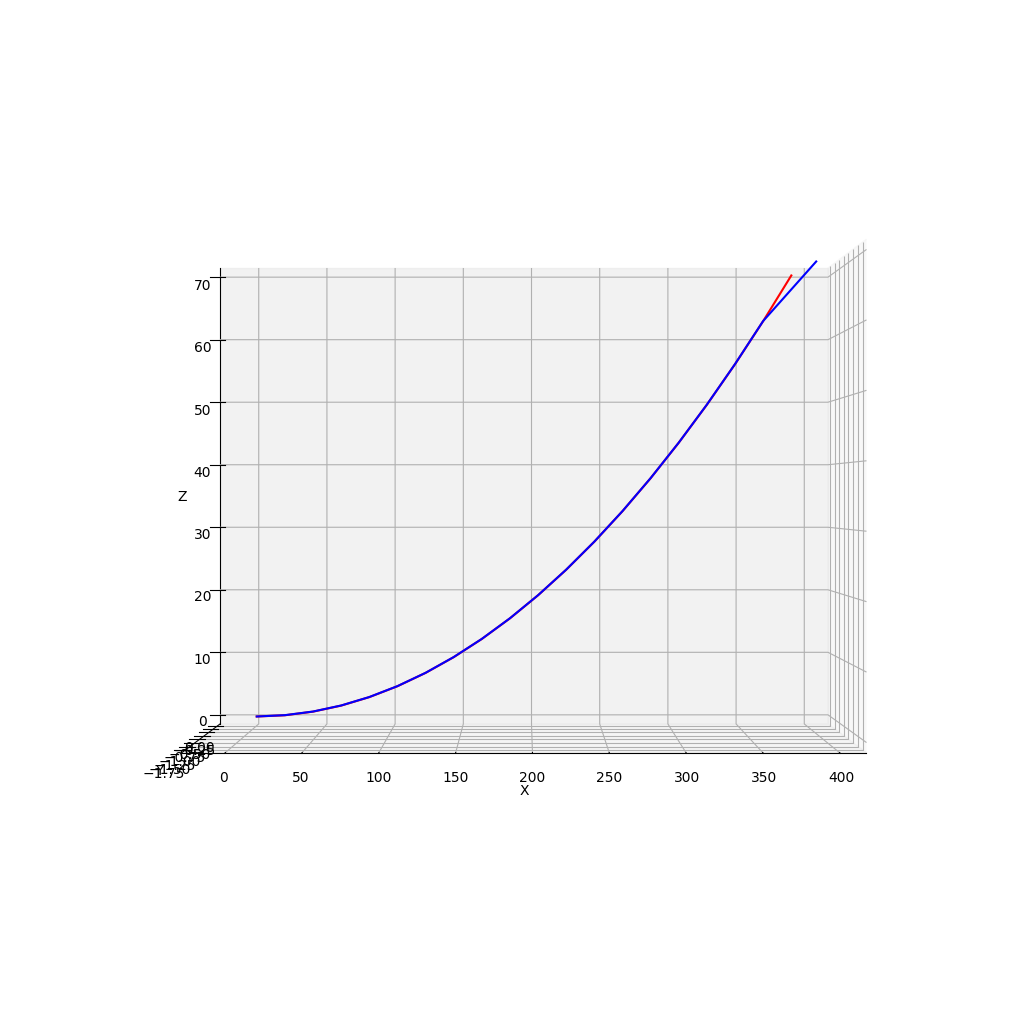

In [112]:
fig=plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection = '3d')

X0=fin[0,[i for i in range(0,N)]]
Y0=fin[0,[i for i in range(2*N,3*N)]]
Z0=fin[0,[i for i in range(4*N,5*N)]]

j=-1
X=fin[j,[i for i in range(0,N)]]
Y=fin[j,[i for i in range(2*N,3*N)]]
Z=fin[j,[i for i in range(4*N,5*N)]]

num_true_pts = 200
tck, u = interpolate.splprep([X,Y,Z], s=2)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot(X0,Y0,Z0, color='r')
ax.plot(X,Y,Z, color='b')
ax.view_init(0,-90)
plt.show()

In [113]:
X,Y,Z

(array([-3.85972292e-27,  2.04750797e+01,  4.09501014e+01,  6.14251230e+01,
         8.19001446e+01,  1.02375166e+02,  1.22850188e+02,  1.43325210e+02,
         1.63800232e+02,  1.84275254e+02,  2.04750276e+02,  2.25225299e+02,
         2.45700321e+02,  2.66175344e+02,  2.86650367e+02,  3.07125390e+02,
         3.27600413e+02,  3.48075426e+02,  3.68541727e+02,  3.86203519e+02]),
 array([ 4.43370902e-25,  6.40653329e-03,  6.42923047e-03,  6.42675807e-03,
         6.42298881e-03,  6.41795913e-03,  6.41166988e-03,  6.40412215e-03,
         6.39531724e-03,  6.38525675e-03,  6.37394251e-03,  6.36137658e-03,
         6.34756129e-03,  6.33249923e-03,  6.31619322e-03,  6.29864637e-03,
         6.27985482e-03,  6.25867984e-03,  4.65787427e-03, -1.77084262e+00]),
 array([-9.05827753e-26,  2.00567605e-01,  7.76379597e-01,  1.73622933e+00,
         3.08048628e+00,  4.80962281e+00,  6.92424643e+00,  9.42510012e+00,
         1.23130625e+01,  1.55891483e+01,  1.92545086e+01,  2.33104311e+01,
        

In [114]:
X0,Y0,Z0

(array([  0.        ,  20.47511082,  40.95022165,  61.42533247,
         81.9004433 , 102.37555412, 122.85066495, 143.32577577,
        163.8008866 , 184.27599742, 204.75110824, 225.22621907,
        245.70132989, 266.17644072, 286.65155154, 307.12666237,
        327.60177319, 348.07688401, 368.55199484, 389.02710566]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]),
 array([ 0.        ,  0.19189866,  0.76766204,  1.72749246,  3.07172714,
         4.80083838,  6.9154337 ,  9.41625605, 12.30418411, 15.58023255,
        19.24555239, 23.30143144, 27.74929474, 32.59070503, 37.82736334,
        43.46110957, 49.49392312, 55.92792361, 62.76537163, 70.00866951]))

In [115]:
us=fin.T

In [116]:
us.shape

(240, 166)

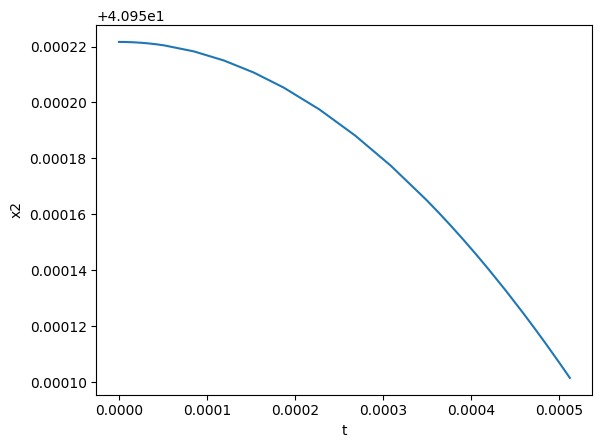

In [117]:
plt.plot(t,us.T[:,2],'-')
plt.xlabel('t')
plt.ylabel('x2')
plt.show()

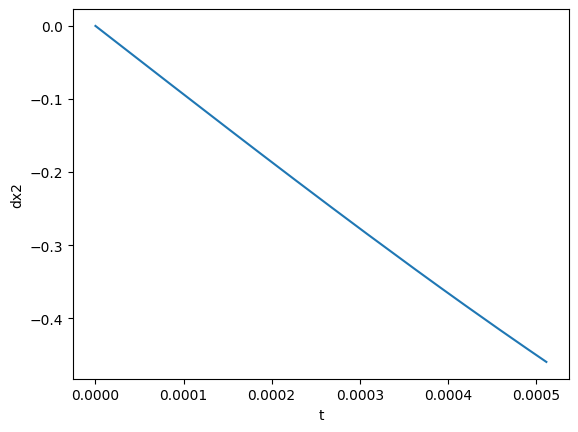

In [118]:
plt.plot(t,us.T[:,N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dx2')
plt.show()

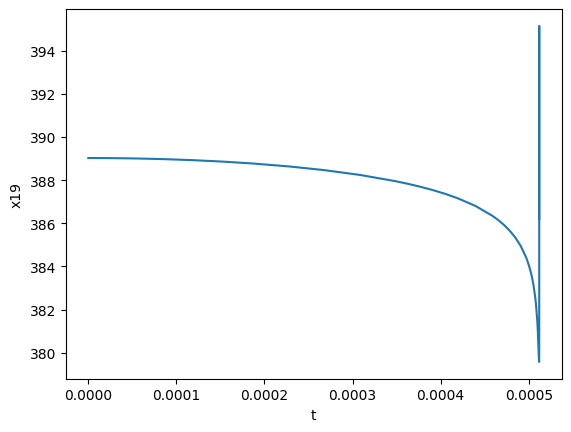

In [119]:
plt.plot(t,us.T[:,N-1] ,'-')
plt.xlabel('t')
plt.ylabel('x{}'.format(N-1))
plt.show()

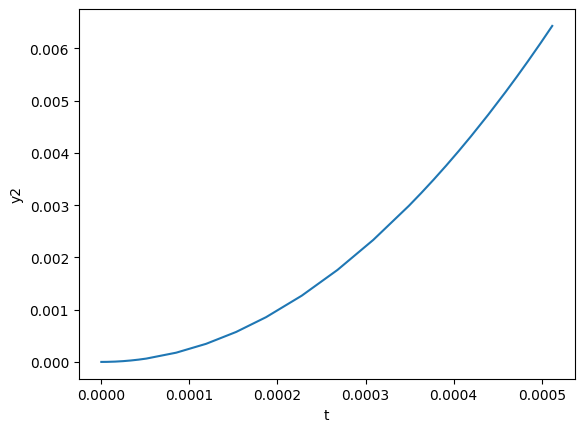

In [120]:
plt.plot(t,us.T[:,2*N +2] ,'-')
plt.xlabel('t')
plt.ylabel('y2')
plt.show()

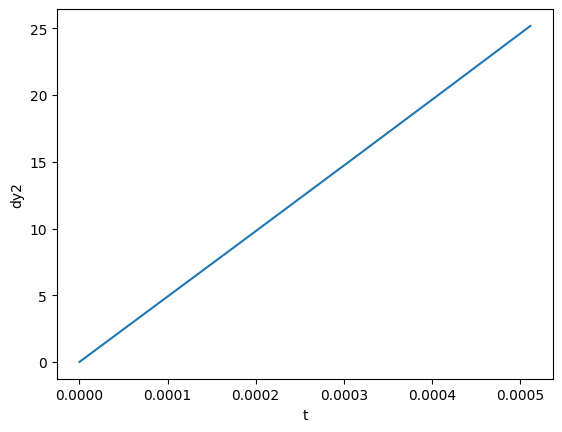

In [121]:
plt.plot(t,us.T[:,3*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dy2')
plt.show()

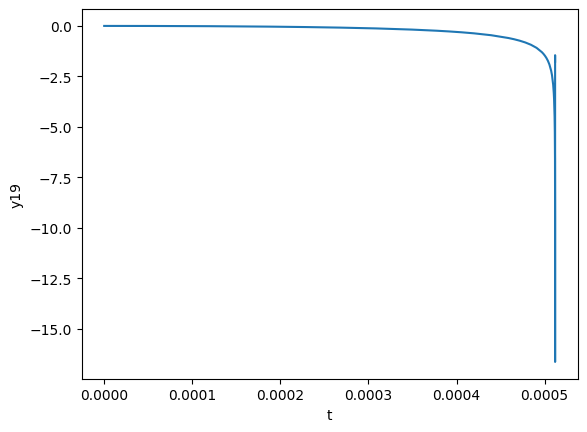

In [122]:
plt.plot(t,us.T[:,2*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('y{}'.format(N-1))
plt.show()

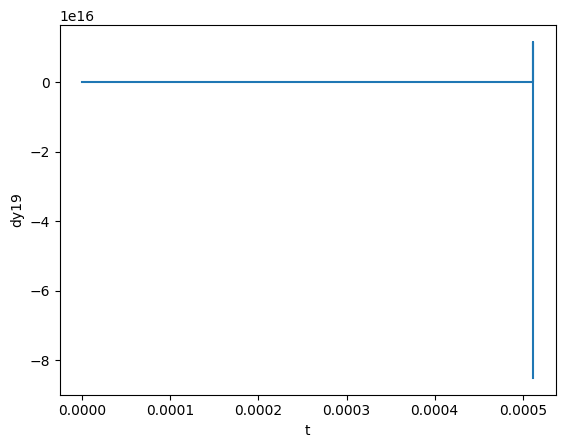

In [123]:
plt.plot(t,us.T[:,3*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('dy{}'.format(N-1))
plt.show()

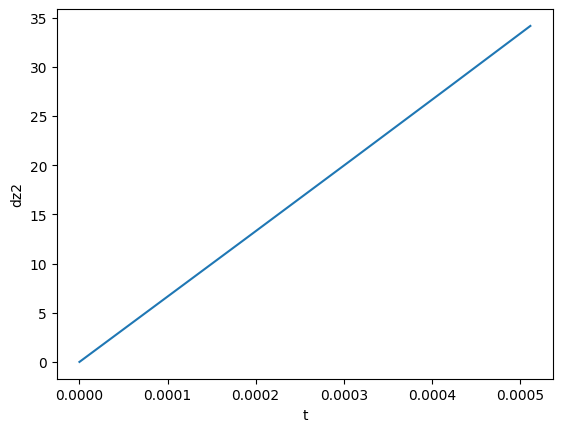

In [124]:
plt.plot(t,us.T[:,5*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dz2')
plt.show()

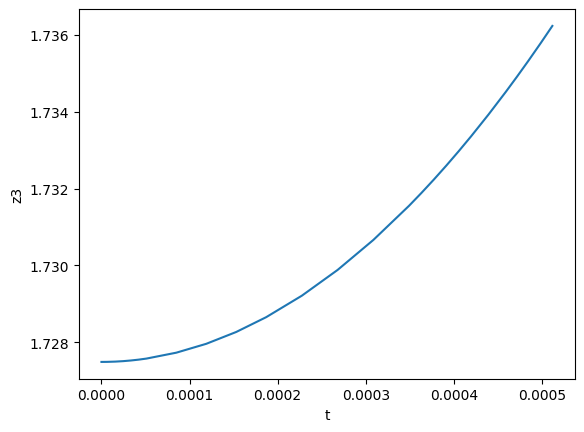

In [125]:
plt.plot(t,us.T[:,4*N+3] ,'-')
plt.xlabel('t')
plt.ylabel('z3')
plt.show()

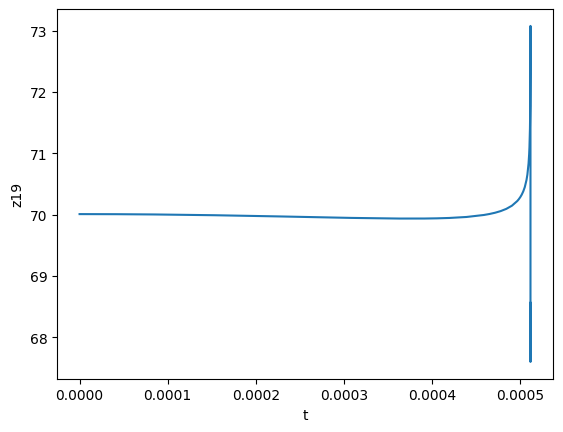

In [126]:
plt.plot(t,us.T[:,4*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('z{}'.format(N-1))
plt.show()

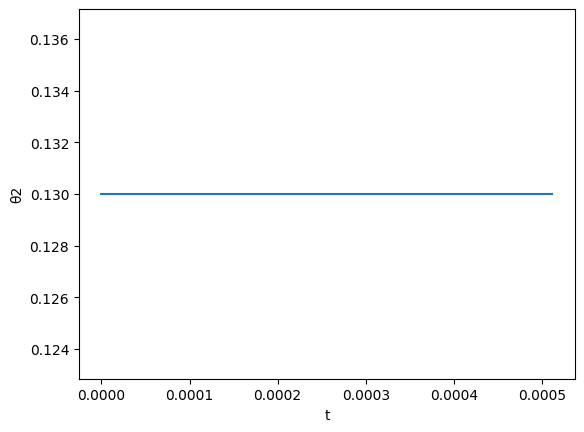

In [127]:
plt.plot(t,us.T[:,8*N+2],'-')
plt.xlabel('t')
plt.ylabel('θ2')
plt.show()

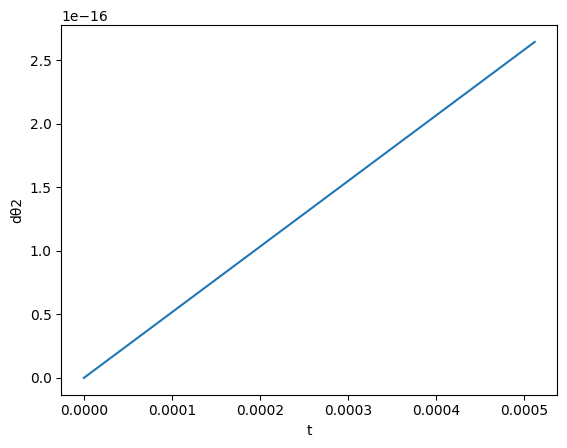

In [128]:
plt.plot(t,us.T[:,9*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dθ2')
plt.show()

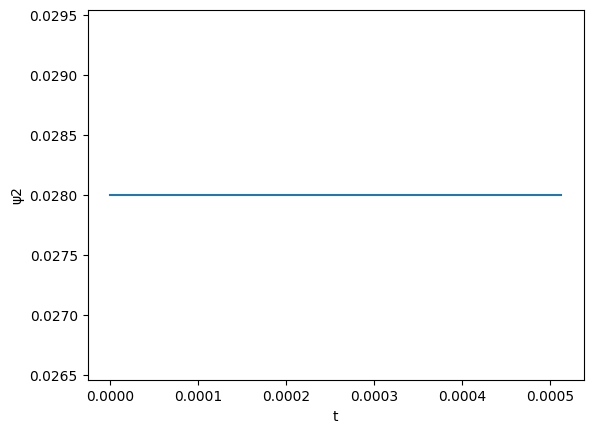

In [129]:
plt.plot(t,us.T[:,10*N+2],'-')
plt.xlabel('t')
plt.ylabel('ψ2')
plt.show()

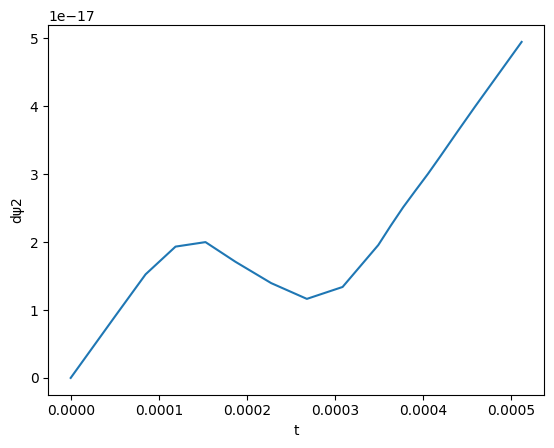

In [130]:
plt.plot(t,us.T[:,11*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dψ2')
plt.show()

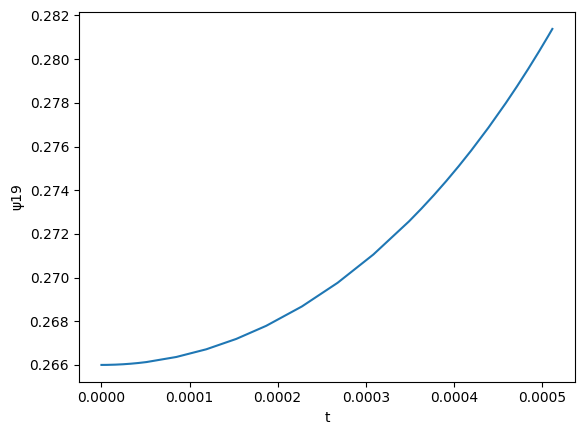

In [131]:
plt.plot(t,us.T[:,10*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('ψ{}'.format(N-1))
plt.show()

In [132]:
X010=us.T[:,0*N:1*N]

In [133]:
Y010=us.T[:,2*N:3*N]

In [134]:
Z010=us.T[:,4*N:5*N]

In [135]:
# simulation = np.stack([X010,Y010,Z010],axis=2) 

# FPS = 5                      
# frame_duration = 1000 / FPS

# frames = []
# for t in range(simulation.shape[0]):
#     x = simulation[t,:,0]
#     y = simulation[t,:,1]
#     z = simulation[t,:,2]

#     frames.append(go.Frame(
#         data=[
#             go.Scatter3d(
#                 x=x, y=y, z=z,
#                 mode="lines+markers",
#                 marker=dict(size=5, color=list(range(12)), colorscale="Viridis"),
#                 line=dict(width=4)
#             )
#         ],
#         name=f"t={t}"
#     ))

# # First frame
# x0, y0, z0 = simulation[0,:,0], simulation[0,:,1], simulation[0,:,2]

# fig = go.Figure(
#     data=[go.Scatter3d(x=x0, y=y0, z=z0, mode="lines+markers")],
#     frames=frames
# )

# # Animation controls
# fig.update_layout(
#     title="Pipeline Simulation ",
#     scene=dict(
#         xaxis_title="X",
#         yaxis_title="Y",
#         zaxis_title="Z",
#         xaxis=dict(range=[0, 400]),
#         yaxis=dict(range=[-50, 50]),
#         zaxis=dict(range=[0, 100]),
#         aspectmode="data",
       
#     ),
#     updatemenus=[{
#         "type": "buttons",
#         "buttons": [
#             {
#                 "label": "Play",
#                 "method": "animate",
#                 "args": [None, {"frame": {"duration": frame_duration, "redraw": True}}]
#             },
#             {
#                 "label": "Pause",
#                 "method": "animate",
#                 "args": [[None], {"frame": {"duration": 0}}]
#             }
#         ]
#     }]
# )

# fig.show()